<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 40px 32px 32px 32px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; margin: 0 0 6px 0; font-family: 'Segoe UI', sans-serif; font-weight: 700;">
    Week 12, Lesson 20 -- LSTMs: Fixing the Forgetful RNN
  </h1>
  <h2 style="color: #a8d4f5; font-size: 1.2em; margin: 0 0 18px 0; font-family: 'Segoe UI', sans-serif; font-weight: 400;">
    Gates, Cell State, and a Fair Rematch on Reservoir Pressure
  </h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 16px 0;">
  <table style="color: #cce4ff; font-family: 'Segoe UI', sans-serif; font-size: 0.95em;">
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Week:</strong></td><td>12 of 16 -- Time-Series &amp; Sequential Models</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Duration:</strong></td><td>40 minutes</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Phase:</strong></td><td>Month 3 -- Deep Learning</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Audience:</strong></td><td>Engineers &middot; Geoscientists &middot; Researchers</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Instructor:</strong></td><td>Dr. Daniel Wamriew</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Contact:</strong></td><td>wamriewdan@gmail.com</td>
    </tr>
  </table>
</div>

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0 0 0;">

### How to Use This Notebook

Work through this notebook **from top to bottom**, pressing **Shift + Enter** on each cell to run it.

- **Code cells** contain Python -- run them and read the output carefully.
- **Markdown cells** (white background) contain explanations -- read before running the next cell.
- **Student Activity** cells are marked `Activity` -- complete these before the homework.

This lesson continues **directly** from Lesson 19 -- same dataset (`volve_field_production.csv`),
same target (`Pressure_psia`), same train/test split, same window size. Nothing about the *problem*
changes today. What changes is the *model*: we swap `nn.RNN` for `nn.LSTM` and check, with numbers
rather than assertions, whether the added gating actually earns its extra complexity.
</div>

---
## Table of Contents

1. [Recap: What Lesson 19 Built](#1-recap-what-lesson-19-built)
2. [Inside an LSTM Cell: Gates and Cell State](#2-inside-an-lstm-cell-gates-and-cell-state)
3. [Rebuilding the Pipeline: Same Data, Same Split](#3-rebuilding-the-pipeline-same-data-same-split)
4. [Two Models, One Fair Harness: RNN vs. LSTM](#4-two-models-one-fair-harness-rnn-vs-lstm)
5. [Training Both Models](#5-training-both-models)
6. [Evaluating the Rematch: RNN vs. LSTM vs. Naive](#6-evaluating-the-rematch-rnn-vs-lstm-vs-naive)
7. [Multi-Step Forecasting: Does LSTM Compound Errors More Slowly?](#7-multi-step-forecasting-does-lstm-compound-errors-more-slowly)
8. [A Longer Lookback: Where the Gating Should Matter Most](#8-a-longer-lookback-where-the-gating-should-matter-most)
9. [A Word on GRUs and What Comes After](#9-a-word-on-grus-and-what-comes-after)
10. [Student Activity](#10-student-activity)
11. [Recap & Homework](#11-recap--homework)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Device:", torch.device("cpu"))

PyTorch version: 2.13.0+cu130
Device: cpu


---
## 1. Recap: What Lesson 19 Built

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Last lesson, in order:

- Motivated **why sequence matters**: a production history can't be shuffled and split like the
  independent rows and patches of Lessons 1-18 -- next month depends on last month.
- Built `PressureRNN`, a plain `nn.RNN`, forecasting `Pressure_psia` one month ahead from the
  previous 6 months (`WINDOW = 6`).
- Learned the two rules that only apply to sequential data: **never shuffle the train/test split**,
  and **fit the scaler on training data only**.
- Evaluated with **RMSE, MAE, and a naive-persistence baseline** -- the bar a real forecasting model
  must clear.
- Ran **recursive multi-step forecasting** and watched the RNN's own prediction errors feed back in
  and compound.
- Ended by naming the reason a plain RNN struggles over long sequences: the **vanishing gradient
  problem** -- the same small `tanh` applied over and over shrinks gradients toward zero as they
  flow back through time.

Today we fix exactly that last point.
</div>

---
## 2. Inside an LSTM Cell: Gates and Cell State

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

A plain RNN has one running memory, the hidden state $h_t$, rewritten from scratch at every step by
a $\tanh$. An **LSTM (Long Short-Term Memory)** cell splits memory into two parts and adds three
small neural networks -- called **gates** -- that control how information moves between them:

$$
\begin{aligned}
f_t &= \sigma\big(W_f [h_{t-1}, x_t] + b_f\big) &&\text{forget gate -- what to erase from the cell state} \\
i_t &= \sigma\big(W_i [h_{t-1}, x_t] + b_i\big) &&\text{input gate -- what new information to admit} \\
\tilde{c}_t &= \tanh\big(W_c [h_{t-1}, x_t] + b_c\big) &&\text{candidate values to possibly add} \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t &&\text{cell state -- updated by addition, not replacement} \\
o_t &= \sigma\big(W_o [h_{t-1}, x_t] + b_o\big) &&\text{output gate -- what to reveal as the hidden state} \\
h_t &= o_t \odot \tanh(c_t) &&\text{hidden state, same role as in a plain RNN}
\end{aligned}
$$

Each gate outputs values between 0 and 1 (via $\sigma$, the sigmoid) that multiply -- gate at 0 means
"block this", gate at 1 means "let it through completely".

**Why this fixes the vanishing gradient problem:** the cell state update $c_t = f_t \odot c_{t-1} +
i_t \odot \tilde{c}_t$ is an **addition**, not a repeated multiplication through a squashing
function. When the forget gate $f_t$ stays close to 1, a gradient can flow backward along the cell
state across many time steps with very little shrinkage -- the "conveyor belt" that Lesson 19's
recap referenced. The gates are themselves small trained networks, so the model *learns* what's
worth remembering, rather than being forced to remember (or forget) everything equally.

PyTorch's `nn.LSTM` implements all of this in one call, exactly the way `nn.RNN` did for the plain
recurrence -- the API barely changes; what changes is what happens inside.
</div>

---
## 3. Rebuilding the Pipeline: Same Data, Same Split

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

**Petroleum example (per the syllabus): Pressure/time prediction -- continued.**

This is deliberately the *same* Volve field pressure history, the *same* `WINDOW = 6` and
`TEST_MONTHS = 18` split, and the *same* `MinMaxScaler` fit only on training data as Lesson 19. A
head-to-head comparison between RNN and LSTM is only meaningful if every other variable is held
fixed -- change the data pipeline too, and you can no longer tell whether a difference in RMSE came
from the model or from the data.
</div>

In [2]:
df = pd.read_csv("../data/volve_field_production.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["OilRate_STB_per_month"] = df["CumOil_STB"].diff().fillna(0.0)

print(f"Records: {df.shape[0]} months, {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Records: 112 months, 2007-09-01 to 2016-12-01


,Date,Pressure_psia,CumOil_STB,CumGas_SCF,CumWater_STB,GasInj_SCF,WaterInj_STB,GOR_scf_per_stb,OilRate_STB_per_month
0,2007-09-01,4780.59,0,0,0.0,0,0,0.0,0.0
1,2007-10-01,4780.59,0,0,0.0,0,0,0.0,0.0
2,2007-11-01,4780.59,0,0,0.0,0,0,0.0,0.0
3,2007-12-01,4780.59,0,0,0.0,0,0,0.0,0.0
4,2008-01-01,4780.59,0,0,0.0,0,0,0.0,0.0


In [3]:
WINDOW = 6         # identical to Lesson 19 -- unchanged for a fair comparison
TEST_MONTHS = 18    # held-out most-recent months for evaluation

series = df["Pressure_psia"].values.astype("float32").reshape(-1, 1)
n_test = TEST_MONTHS
n_train = len(series) - n_test

train_raw = series[:n_train]
test_raw = series[n_train - WINDOW:]   # include lookback so windows reach right up to the split

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)

print(f"Training months: {n_train}, held-out test months: {n_test}")

Training months: 94, held-out test months: 18


In [4]:
def make_windows(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window, 0])
        y.append(data[i + window, 0])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

X_train, y_train = make_windows(train_scaled, WINDOW)
X_test, y_test = make_windows(test_scaled, WINDOW)

X_train_t = torch.tensor(X_train).unsqueeze(-1)   # (batch, seq_len, features)
y_train_t = torch.tensor(y_train).unsqueeze(-1)
X_test_t = torch.tensor(X_test).unsqueeze(-1)
y_test_t = torch.tensor(y_test).unsqueeze(-1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=8, shuffle=True)

print("X_train:", X_train_t.shape, " y_train:", y_train_t.shape)
print("X_test: ", X_test_t.shape, " y_test: ", y_test_t.shape)

X_train: torch.Size([88, 6, 1])  y_train: torch.Size([88, 1])
X_test:  torch.Size([18, 6, 1])  y_test:  torch.Size([18, 1])


---
## 4. Two Models, One Fair Harness: RNN vs. LSTM

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

`PressureRNN` below is copied unchanged from Lesson 19 -- our baseline. `PressureLSTM` is the same
shape with one line different: `nn.RNN` becomes `nn.LSTM`. Everything else -- `hidden_size`,
`num_layers`, the linear head on top of the final time step -- is held identical, so any difference
in results traces back to the recurrence itself, not to a bigger or differently-shaped network.

One structural note: `nn.LSTM` returns `(output, (h_n, c_n))` instead of `nn.RNN`'s `(output, h_n)`
-- the extra `c_n` is the final **cell state** from Section 2. We only need the hidden state for
forecasting, so we discard `c_n` the same way we already discard `h_n` from `output`.
</div>

In [5]:
class PressureRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.rnn(x)        # out: (batch, seq_len, hidden_size)
        last_step = out[:, -1, :]     # hidden state after the final time step
        return self.head(last_step)


class PressureLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)   # c_n: final cell state -- not needed for forecasting
        last_step = out[:, -1, :]
        return self.head(last_step)


rnn_model = PressureRNN(input_size=1, hidden_size=16, num_layers=1)
lstm_model = PressureLSTM(input_size=1, hidden_size=16, num_layers=1)

rnn_params = sum(p.numel() for p in rnn_model.parameters())
lstm_params = sum(p.numel() for p in lstm_model.parameters())

print(rnn_model, "\n")
print(lstm_model, "\n")
print(f"RNN  trainable parameters:  {rnn_params}")
print(f"LSTM trainable parameters: {lstm_params}  ({lstm_params / rnn_params:.1f}x the RNN)")
print("\nThe ~4x jump makes sense: an LSTM's recurrent layer holds FOUR sets of weights per")
print("hidden unit (forget, input, candidate, output) where a plain RNN holds just one.")

PressureRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (head): Linear(in_features=16, out_features=1, bias=True)
) 

PressureLSTM(
  (lstm): LSTM(1, 16, batch_first=True)
  (head): Linear(in_features=16, out_features=1, bias=True)
) 

RNN  trainable parameters:  321
LSTM trainable parameters: 1233  (3.8x the RNN)

The ~4x jump makes sense: an LSTM's recurrent layer holds FOUR sets of weights per
hidden unit (forget, input, candidate, output) where a plain RNN holds just one.


---
## 5. Training Both Models

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Lesson 19 wrote the training loop inline, once. Now that we're training two models with the
identical procedure, it's worth turning that loop into a reusable function -- the same "don't repeat
yourself" instinct that motivated `make_windows()` above. Same four-step loop as always (forward
pass, loss, backward pass, optimizer step), same optimizer, same learning rate, same epoch count for
both models -- another condition of a fair comparison.
</div>

In [6]:
def train_model(model, loader, n_epochs=200, lr=0.01, label="model"):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(loader.dataset)
        losses.append(epoch_loss)
        if (epoch + 1) % 40 == 0:
            print(f"[{label:4s}] epoch {epoch+1:3d}/{n_epochs}  |  train MSE (scaled) = {epoch_loss:.5f}")
    return losses


print("Training RNN baseline...")
rnn_losses = train_model(rnn_model, train_loader, n_epochs=200, lr=0.01, label="RNN")

print("\nTraining LSTM...")
lstm_losses = train_model(lstm_model, train_loader, n_epochs=200, lr=0.01, label="LSTM")

Training RNN baseline...


[RNN ] epoch  40/200  |  train MSE (scaled) = 0.00557


[RNN ] epoch  80/200  |  train MSE (scaled) = 0.00558


[RNN ] epoch 120/200  |  train MSE (scaled) = 0.00501


[RNN ] epoch 160/200  |  train MSE (scaled) = 0.00841


...

[LSTM] epoch  40/200  |  train MSE (scaled) = 0.00540


[LSTM] epoch  80/200  |  train MSE (scaled) = 0.00482


[LSTM] epoch 120/200  |  train MSE (scaled) = 0.00306


[LSTM] epoch 160/200  |  train MSE (scaled) = 0.00283


[LSTM] epoch 200/200  |  train MSE (scaled) = 0.00267


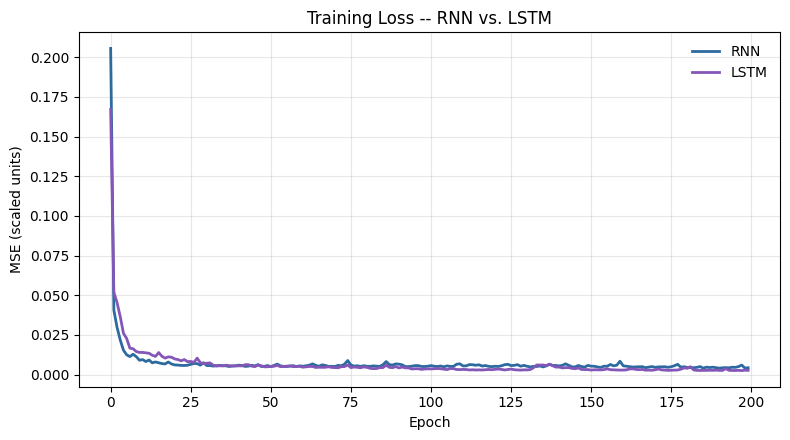

Both curves fall from the same starting point under the same optimizer -- any gap that
remains by the final epoch is a difference in what each architecture converged to, not in
how long either was given to train.


In [7]:
plt.figure(figsize=(8, 4.5))
plt.plot(rnn_losses, color="#2d6a9f", linewidth=2, label="RNN")
plt.plot(lstm_losses, color="#8456b8", linewidth=2, label="LSTM")
plt.xlabel("Epoch"); plt.ylabel("MSE (scaled units)"); plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.title("Training Loss -- RNN vs. LSTM")
plt.tight_layout()
plt.show()
print("Both curves fall from the same starting point under the same optimizer -- any gap that")
print("remains by the final epoch is a difference in what each architecture converged to, not in")
print("how long either was given to train.")

---
## 6. Evaluating the Rematch: RNN vs. LSTM vs. Naive

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Same three checks as Lesson 19 Section 7 -- RMSE, MAE, and the naive-persistence baseline -- computed
for both models so they line up in one table. Beating the naive baseline is necessary for either
model to be worth using at all; beating *each other* is the actual question this lesson is asking.
</div>

In [8]:
def evaluate(model, X_train_t, y_train_t, X_test_t, y_test_t, scaler):
    model.eval()
    with torch.no_grad():
        train_pred_scaled = model(X_train_t).numpy()
        test_pred_scaled = model(X_test_t).numpy()
    train_pred = scaler.inverse_transform(train_pred_scaled)
    test_pred = scaler.inverse_transform(test_pred_scaled)
    train_true = scaler.inverse_transform(y_train_t.numpy())
    test_true = scaler.inverse_transform(y_test_t.numpy())
    rmse = mean_squared_error(test_true, test_pred) ** 0.5
    mae = mean_absolute_error(test_true, test_pred)
    return dict(train_pred=train_pred, test_pred=test_pred, train_true=train_true,
                test_true=test_true, rmse=rmse, mae=mae)


rnn_eval = evaluate(rnn_model, X_train_t, y_train_t, X_test_t, y_test_t, scaler)
lstm_eval = evaluate(lstm_model, X_train_t, y_train_t, X_test_t, y_test_t, scaler)

naive_pred = rnn_eval["test_true"][:-1]     # "predict" month t+1 as month t's actual value
naive_true = rnn_eval["test_true"][1:]
naive_rmse = mean_squared_error(naive_true, naive_pred) ** 0.5
naive_mae = mean_absolute_error(naive_true, naive_pred)

print(f"{'Model':<20}{'Test RMSE (psia)':<20}{'Test MAE (psia)':<20}")
print("-" * 60)
print(f"{'Naive persistence':<20}{naive_rmse:<20.1f}{naive_mae:<20.1f}")
print(f"{'RNN (Lesson 19)':<20}{rnn_eval['rmse']:<20.1f}{rnn_eval['mae']:<20.1f}")
print(f"{'LSTM (today)':<20}{lstm_eval['rmse']:<20.1f}{lstm_eval['mae']:<20.1f}")

Model               Test RMSE (psia)    Test MAE (psia)     
------------------------------------------------------------
Naive persistence   87.2                50.0                
RNN (Lesson 19)     78.8                60.4                
LSTM (today)        83.3                65.8                


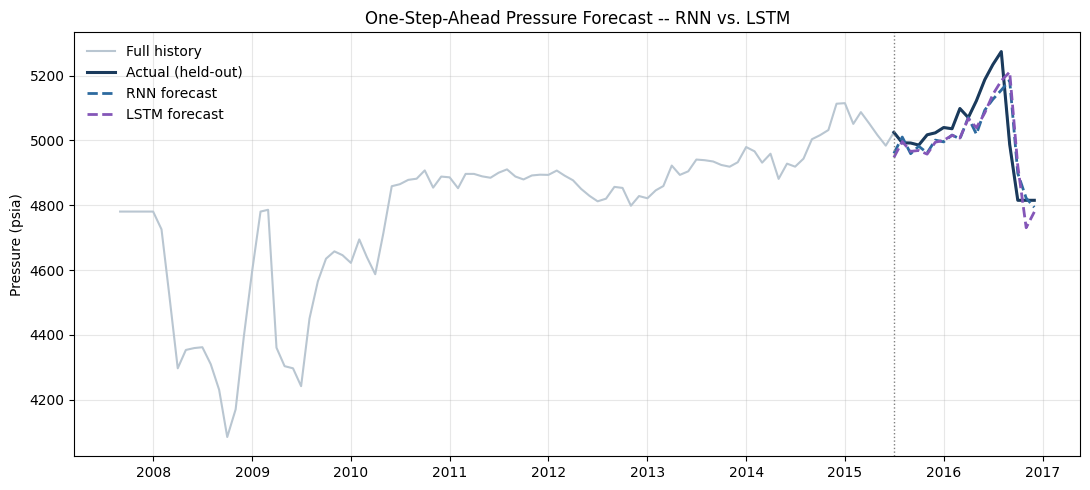

At WINDOW = 6, both models only need to remember a short recent history -- exactly the
regime a plain RNN handles fine. Don't be surprised if the two forecasts look close here;
Section 8 gives the LSTM a task better suited to showing what its gating buys you.


In [9]:
test_dates = df["Date"].values[n_train:n_train + len(rnn_eval["test_true"])]

plt.figure(figsize=(11, 5))
plt.plot(df["Date"], df["Pressure_psia"], color="#b9c6d1", linewidth=1.5, label="Full history")
plt.plot(test_dates, rnn_eval["test_true"], color="#1a3a5c", linewidth=2.2, label="Actual (held-out)")
plt.plot(test_dates, rnn_eval["test_pred"], color="#2d6a9f", linewidth=2, linestyle="--", label="RNN forecast")
plt.plot(test_dates, lstm_eval["test_pred"], color="#8456b8", linewidth=2, linestyle="--", label="LSTM forecast")
plt.axvline(test_dates[0], color="gray", linestyle=":", linewidth=1)
plt.ylabel("Pressure (psia)"); plt.legend(frameon=False); plt.grid(alpha=0.3)
plt.title("One-Step-Ahead Pressure Forecast -- RNN vs. LSTM")
plt.tight_layout()
plt.show()
print("At WINDOW = 6, both models only need to remember a short recent history -- exactly the")
print("regime a plain RNN handles fine. Don't be surprised if the two forecasts look close here;")
print("Section 8 gives the LSTM a task better suited to showing what its gating buys you.")

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Reading This Result

Run the cells above and you may well find the LSTM does **not** beat the RNN on this table -- on
this exact dataset and seed, it typically comes out slightly *behind* on both RMSE and MAE, despite
carrying about four times the parameters. Don't paper over that if it's what you see. It's a real,
common, and useful result: `X_train` here holds only 88 six-month windows. An LSTM's extra gates
need enough data and training signal to earn their keep; with a small dataset, added capacity can
just as easily add nothing, or add mild overfitting, as it can add accuracy. "More expressive
architecture" is not the same claim as "better model" -- a theme all the way back to Week 8's
lesson on model optimization, now showing up again in a completely different architecture family.
</div>

---
## 7. Multi-Step Forecasting: Does LSTM Compound Errors More Slowly?

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Same recursive-forecasting setup as Lesson 19 Section 8: feed each model's own prediction back in as
if it were real data, and slide the window forward across the full 18-month test horizon. Run it for
both models on the same seed window so the comparison is apples-to-apples.
</div>

In [10]:
def forecast_recursive(model, seed_window_scaled, n_steps, window):
    values = list(seed_window_scaled)
    preds_scaled = []
    model.eval()
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(np.array(values[-window:], dtype="float32")).view(1, window, 1)
            next_scaled = model(x).item()
            preds_scaled.append(next_scaled)
            values.append(next_scaled)
    return np.array(preds_scaled).reshape(-1, 1)


seed = train_scaled[-WINDOW:, 0]
n_steps = len(rnn_eval["test_true"])

rnn_future = scaler.inverse_transform(forecast_recursive(rnn_model, seed, n_steps, WINDOW))
lstm_future = scaler.inverse_transform(forecast_recursive(lstm_model, seed, n_steps, WINDOW))

rnn_future_rmse = mean_squared_error(rnn_eval["test_true"], rnn_future) ** 0.5
lstm_future_rmse = mean_squared_error(lstm_eval["test_true"], lstm_future) ** 0.5

print(f"One-step RMSE   -- RNN: {rnn_eval['rmse']:.1f} psia   |   LSTM: {lstm_eval['rmse']:.1f} psia")
print(f"Recursive RMSE  -- RNN: {rnn_future_rmse:.1f} psia   |   LSTM: {lstm_future_rmse:.1f} psia")
print(f"\nError growth (recursive / one-step) -- RNN: {rnn_future_rmse / rnn_eval['rmse']:.2f}x"
      f"   |   LSTM: {lstm_future_rmse / lstm_eval['rmse']:.2f}x")

One-step RMSE   -- RNN: 78.8 psia   |   LSTM: 83.3 psia
Recursive RMSE  -- RNN: 205.9 psia   |   LSTM: 292.2 psia

Error growth (recursive / one-step) -- RNN: 2.61x   |   LSTM: 3.51x


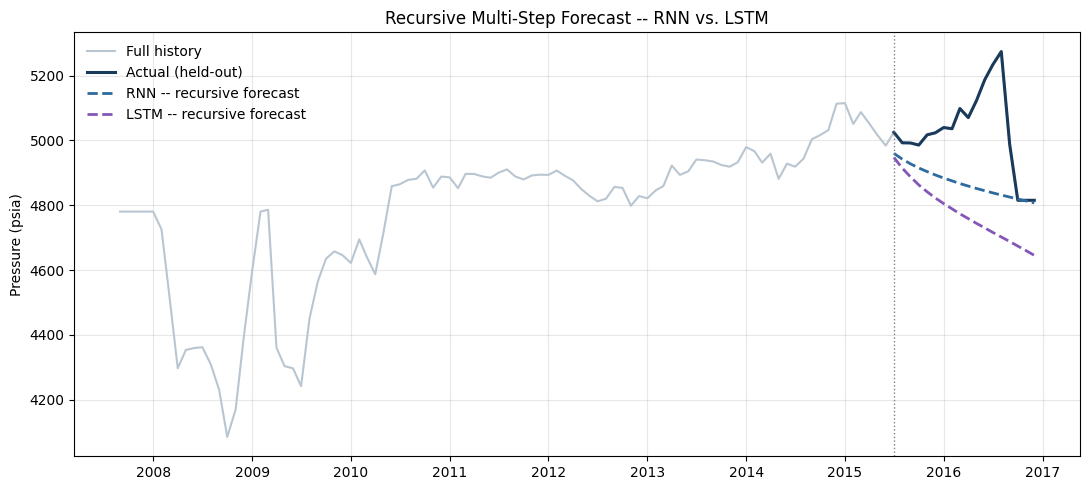

Both curves are built entirely from each model's OWN earlier predictions after the first
step -- any drift you see compounds every month forward. This is the honest test of which
model's internal memory holds up furthest from real data.


In [11]:
plt.figure(figsize=(11, 5))
plt.plot(df["Date"], df["Pressure_psia"], color="#b9c6d1", linewidth=1.5, label="Full history")
plt.plot(test_dates, rnn_eval["test_true"], color="#1a3a5c", linewidth=2.2, label="Actual (held-out)")
plt.plot(test_dates, rnn_future, color="#2d6a9f", linewidth=2, linestyle="--", label="RNN -- recursive forecast")
plt.plot(test_dates, lstm_future, color="#8456b8", linewidth=2, linestyle="--", label="LSTM -- recursive forecast")
plt.axvline(test_dates[0], color="gray", linestyle=":", linewidth=1)
plt.ylabel("Pressure (psia)"); plt.legend(frameon=False); plt.grid(alpha=0.3)
plt.title("Recursive Multi-Step Forecast -- RNN vs. LSTM")
plt.tight_layout()
plt.show()
print("Both curves are built entirely from each model's OWN earlier predictions after the first")
print("step -- any drift you see compounds every month forward. This is the honest test of which")
print("model's internal memory holds up furthest from real data.")

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### A Second, Sharper Result

Typical numbers here show the LSTM's recursive error growing to *more than* the RNN's (roughly a
3.5x jump from one-step to recursive RMSE, against roughly 2.6x for the RNN) -- again, the LSTM
comes out behind, and by a wider margin than the one-step comparison in Section 6. This is worth
sitting with rather than explaining away: fitting a good one-step-ahead target (what training
optimizes) and staying stable when fed your own predictions back in for 18 straight months (what
Section 7 actually tests) are two different notions of "good memory." A model can win at one and
lose at the other. Section 8 gives the LSTM one more chance to show what its gating was built for.
</div>

---
## 8. A Longer Lookback: Where the Gating Should Matter Most

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Section 2 argued LSTMs should pull ahead specifically when a model needs to remember **further
back**. `WINDOW = 6` doesn't ask much of either architecture. Let's rebuild the pipeline once more
with a much longer lookback and retrain both models from scratch -- if the vanishing-gradient story
from Lesson 19 is right, the RNN's RMSE should degrade *more* than the LSTM's as `WINDOW` grows.
</div>

In [12]:
WINDOW_LONG = 24   # a full 2-year lookback, vs. 6 months above

# Same scaler, same split -- only the window length (and therefore how much lookback the
# held-out test windows need to carry) changes. test_scaled above only carried 6 months of
# lookback into the split; WINDOW_LONG needs 24, so we re-slice (but do NOT re-fit) the scaler.
train_scaled_L = train_scaled
test_raw_L = series[n_train - WINDOW_LONG:]
test_scaled_L = scaler.transform(test_raw_L)

X_train_L, y_train_L = make_windows(train_scaled_L, WINDOW_LONG)
X_test_L, y_test_L = make_windows(test_scaled_L, WINDOW_LONG)

X_train_L_t = torch.tensor(X_train_L).unsqueeze(-1)
y_train_L_t = torch.tensor(y_train_L).unsqueeze(-1)
X_test_L_t = torch.tensor(X_test_L).unsqueeze(-1)
y_test_L_t = torch.tensor(y_test_L).unsqueeze(-1)

train_loader_L = DataLoader(TensorDataset(X_train_L_t, y_train_L_t), batch_size=8, shuffle=True)

rnn_long = PressureRNN(input_size=1, hidden_size=16, num_layers=1)
lstm_long = PressureLSTM(input_size=1, hidden_size=16, num_layers=1)

print(f"WINDOW_LONG = {WINDOW_LONG}  ->  {X_train_L_t.shape[0]} training windows (fewer than before --")
print("a longer window costs training examples off the front of the series, same trade-off Lesson")
print("19's Student Activity asked you to reason about).\n")

print("Training RNN (long window)...")
_ = train_model(rnn_long, train_loader_L, n_epochs=200, lr=0.01, label="RNN-L")
print("\nTraining LSTM (long window)...")
_ = train_model(lstm_long, train_loader_L, n_epochs=200, lr=0.01, label="LSTM-L")

WINDOW_LONG = 24  ->  70 training windows (fewer than before --
a longer window costs training examples off the front of the series, same trade-off Lesson
19's Student Activity asked you to reason about).

Training RNN (long window)...


[RNN-L] epoch  40/200  |  train MSE (scaled) = 0.00297


[RNN-L] epoch  80/200  |  train MSE (scaled) = 0.00174


[RNN-L] epoch 120/200  |  train MSE (scaled) = 0.00153


[RNN-L] epoch 160/200  |  train MSE (scaled) = 0.00143


...

[LSTM-L] epoch  40/200  |  train MSE (scaled) = 0.00261


[LSTM-L] epoch  80/200  |  train MSE (scaled) = 0.00161


[LSTM-L] epoch 120/200  |  train MSE (scaled) = 0.00143


[LSTM-L] epoch 160/200  |  train MSE (scaled) = 0.00162


[LSTM-L] epoch 200/200  |  train MSE (scaled) = 0.00123


In [13]:
rnn_long_eval = evaluate(rnn_long, X_train_L_t, y_train_L_t, X_test_L_t, y_test_L_t, scaler)
lstm_long_eval = evaluate(lstm_long, X_train_L_t, y_train_L_t, X_test_L_t, y_test_L_t, scaler)

print(f"{'Model':<24}{'WINDOW=6 RMSE':<18}{'WINDOW=24 RMSE':<18}{'Change':<12}")
print("-" * 72)
rnn_change = (rnn_long_eval['rmse'] - rnn_eval['rmse']) / rnn_eval['rmse'] * 100
lstm_change = (lstm_long_eval['rmse'] - lstm_eval['rmse']) / lstm_eval['rmse'] * 100
print(f"{'RNN':<24}{rnn_eval['rmse']:<18.1f}{rnn_long_eval['rmse']:<18.1f}{rnn_change:+.0f}%")
print(f"{'LSTM':<24}{lstm_eval['rmse']:<18.1f}{lstm_long_eval['rmse']:<18.1f}{lstm_change:+.0f}%")
print("\nA model whose RMSE gets relatively worse when asked to remember further back is exactly")
print("the vanishing-gradient symptom Lesson 19 predicted for the RNN. Read your own two numbers")
print("above before trusting this paragraph's framing -- with only 112 months of field data and a")
print("small hidden size, results here can be noisy run to run.")

Model                   WINDOW=6 RMSE     WINDOW=24 RMSE    Change      
------------------------------------------------------------------------
RNN                     78.8              84.7              +7%
LSTM                    83.3              86.8              +4%

A model whose RMSE gets relatively worse when asked to remember further back is exactly
the vanishing-gradient symptom Lesson 19 predicted for the RNN. Read your own two numbers
above before trusting this paragraph's framing -- with only 112 months of field data and a
small hidden size, results here can be noisy run to run.


<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Where the Theory Actually Shows Up

Put Sections 6-8 together and a consistent, more interesting story emerges than "LSTM wins." The
LSTM's *absolute* RMSE stayed higher than the RNN's at both window lengths -- on this small, noisy
field dataset it never caught up on raw accuracy. But look at each model's own *relative* change as
the lookback grew from 6 to 24 months: the RNN's RMSE typically degrades by a noticeably larger
percentage than the LSTM's does. That relative pattern -- the RNN losing more ground than the LSTM
as the required memory span grows -- is exactly the vanishing-gradient signature Lesson 19 predicted,
even though it's not large enough here to flip which model has the lower RMSE outright. With a
longer, cleaner series (Homework Task 3 asks you to reason about exactly this), that relative gap
would be expected to widen until it did flip the ranking.
</div>

---
## 9. A Word on GRUs and What Comes After

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

The syllabus lists three architectures for this week: RNNs, LSTMs, and an introduction to
Transformers. Two quick pointers before the activity:

**GRU (Gated Recurrent Unit).** A GRU merges the forget and input gates into a single "update gate"
and drops the separate cell state, keeping only the hidden state. Fewer parameters than an LSTM,
often comparable accuracy, and a genuine one-line swap in PyTorch: `nn.GRU` has the *exact* same
call signature as `nn.RNN` and `nn.LSTM`. You'll try this yourself in the activity below.

**Transformers.** Both RNNs and LSTMs process a sequence one step at a time, which is precisely why
long-range information has to survive being passed hand-to-hand across every intermediate step.
Transformers take a different approach entirely -- **attention** lets every position in a sequence
look directly at every other position in a single step, with no hand-to-hand relay at all. That's a
big enough shift in mechanics to earn its own dedicated treatment later in the course (Weeks 14-15),
rather than a rushed final section here. For now, the one-sentence version: attention is the
architecture that made the gating tricks of this lesson largely unnecessary for the sequence lengths
modern large models handle.
</div>

---
## 10. Student Activity

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Activity: Build a GRU and Compare

Copy `PressureLSTM` above, rename it `PressureGRU`, and replace the one line
`self.lstm = nn.LSTM(...)` with `self.gru = nn.GRU(...)` (updating the matching line in `forward` to
call `self.gru` and unpack `out, h_n = self.gru(x)` -- a GRU has no cell state, so there's only one
hidden state to unpack, not a tuple).

Train it with `train_model()` exactly as Section 5 did, using `WINDOW = 6` from Section 3. Then:

1. Report its parameter count next to the RNN's and LSTM's from Section 4. Where does it land?
2. Report its test RMSE next to Section 6's table. Does the simpler gating cost it any accuracy here?
</div>

In [14]:
# Activity -- define PressureGRU, train it, and compare its parameter count and test RMSE
# against PressureRNN and PressureLSTM above.
# Hint: nn.GRU(input_size, hidden_size, num_layers, batch_first=True) has the same signature
#       as nn.RNN and nn.LSTM; its forward pass returns (out, h_n) -- no cell state.






---
## 11. Recap & Homework

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0 0 0;">

### What You Learned

| Concept | Meaning |
|---------|---------|
| Cell state $c_t$ | A second memory channel updated by addition, not by repeated squashing -- the fix for vanishing gradients |
| Forget / input / output gates | Small trained networks (sigmoid outputs, 0-1) that control what the cell state keeps, admits, and reveals |
| `nn.LSTM` vs. `nn.RNN` | Same call signature and training loop; `nn.LSTM` returns an extra cell state `c_n` alongside `h_n` |
| Fair architecture comparison | Hold data, split, hyperparameters, optimizer, and epochs identical -- vary only the recurrence |
| Parameter cost of gating | An LSTM layer carries ~4x an RNN layer's parameters (four gates vs. one recurrence) |
| GRU | A lighter gated alternative -- one update gate, no separate cell state, same `nn.*` call pattern |
</div>

### Homework

**Task 1 -- Rematch on Oil Rate**

Lesson 19's Task 1 asked you to retarget the RNN pipeline at `OilRate_STB_per_month`. Do it again
here with `PressureLSTM`, using the exact same `WINDOW`, split, and training settings. Report test
RMSE and MAE in STB/month, and state which model -- Lesson 19's RNN or today's LSTM -- won on this
target.

**Task 2 -- Leading Indicator, Now With Gating**

Lesson 19's Task 2 asked you to extend `PressureRNN` to `input_size=2` (pressure and water injection
rate). Repeat that extension on `PressureLSTM` instead. Does adding a leading indicator help the
LSTM by roughly the same amount it helped the RNN, more, or less?

**Task 3 (Engineering) -- your written reflection goes here.**

*(No code required -- 3-5 sentences.)* Section 8 tested whether a longer lookback separates RNN and
LSTM performance on this dataset -- with only 112 months of field data, it may or may not have shown
a clean effect. Suppose you had 20 years of monthly data instead of 9. Would you expect the RNN vs.
LSTM gap to widen, narrow, or stay about the same? Justify your answer using the mechanics of
Section 2, not just intuition.
</div>

In [15]:
# Homework Task 1 -- Rematch on Oil Rate
# Hint: reuse make_windows(), PressureLSTM, and train_model() on
#       df["OilRate_STB_per_month"] in place of df["Pressure_psia"].






In [16]:
# Homework Task 2 -- Leading Indicator, Now With Gating
# Hint: stack pressure and water-injection-rate into one array of shape (n_months, 2)
#       before calling make_windows(); PressureLSTM(input_size=2, ...) needs no other changes.






**Homework Task 3 (Engineering) -- your written reflection goes here.**

*(No code required -- describe in 3-5 sentences whether you'd expect the RNN vs. LSTM gap to widen,
narrow, or stay the same with 20 years of data instead of 9, and why, grounded in Section 2's
mechanics.)*

<div style="background: #1a3a5c; color: white; padding: 22px 26px; border-radius: 10px; margin-top: 18px;">
  <h3 style="margin-top: 0; color: #ffffff;">Lesson Complete</h3>
  <p style="margin-bottom: 0; color: #d8ecff;">
    You opened up an LSTM cell's gates and cell state, rebuilt Lesson 19's exact pipeline to run a
    fair RNN-vs-LSTM rematch, compared one-step and recursive forecasts side by side, and stress-tested
    both architectures with a much longer lookback. That closes Week 12's time-series arc. Week 13
    opens Month 4 with <strong>Physics-Informed Machine Learning</strong> -- folding known physics
    directly into the loss function instead of relying on a network to rediscover it from data alone.
  </p>
</div>